In [31]:
date    = "2018-06-15"               
types   = ["load", "wind", "solar"]  
out_dir = "/Users/val/Desktop/Princeton"

# ← change according to type
load_zone   = "Coast"                # Coast, East, Far_West, North, North_Central, South, South_Central, West
wind_asset  = "Aguayo Wind"          # any wind asset name
solar_asset = "Adamstown Solar"      # any solar asset name

In [32]:
import subprocess, bz2, pickle, os
from datetime import datetime

os.chdir(out_dir)

d = datetime.strptime(date, "%Y-%m-%d")
pkl_path = f"{out_dir}/scens_{d.year}-{str(d.month).zfill(2)}-{str(d.day).zfill(2)}.p.gz"

raw = {}

for t in types:
    print(f"\nGenerating {t} scenarios for {date}...")
    subprocess.run(f"pgscen-{t} {date} 1 -p", shell=True, check=True)

    with bz2.open(pkl_path, "rb") as f:
        data = pickle.load(f)
    
    for key in data.keys():
        raw[key] = data[key]

print("\nKeys available:", raw.keys())
print("All scenarios generated successfully!")


Generating load scenarios for 2018-06-15...

Generating wind scenarios for 2018-06-15...

Generating solar scenarios for 2018-06-15...

Keys available: dict_keys(['Load', 'Wind', 'Solar'])
All scenarios generated successfully!


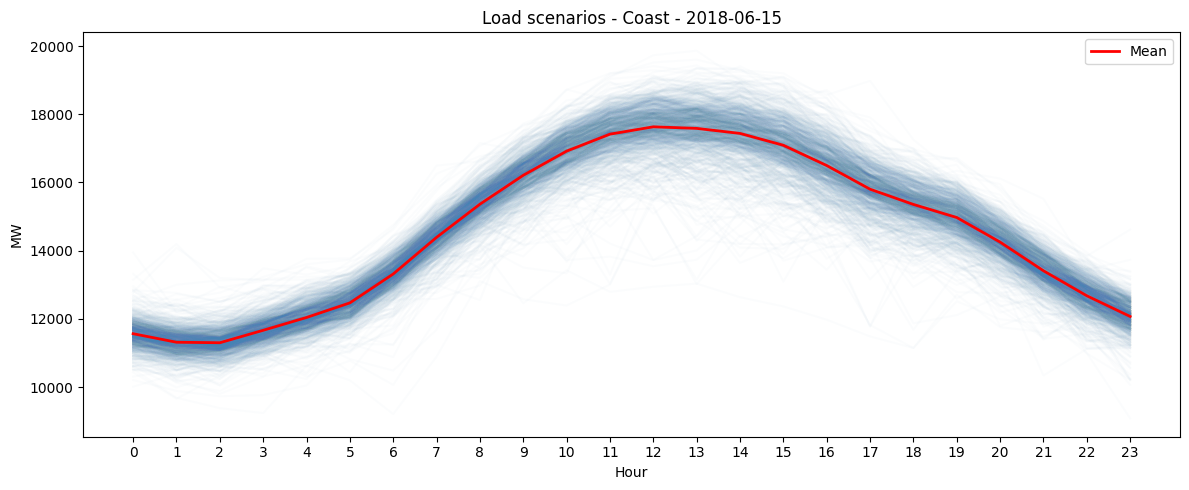

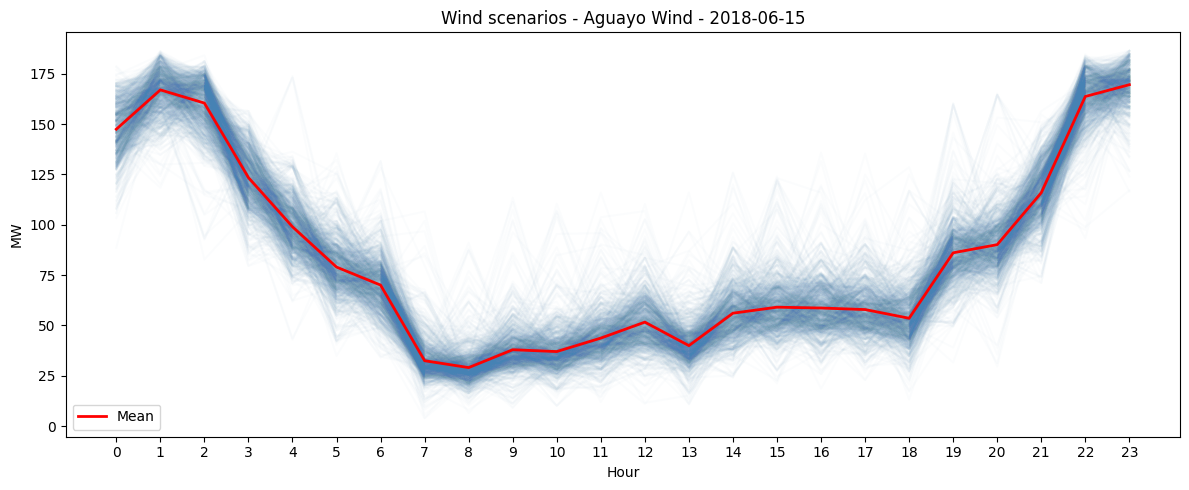

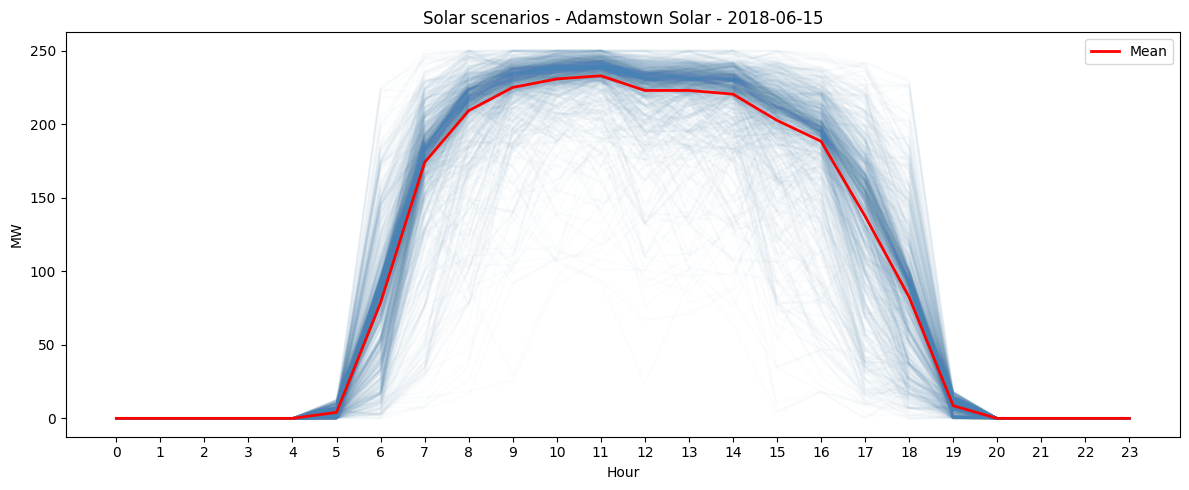

In [33]:
import matplotlib.pyplot as plt

type_map = {"load": "Load", "wind": "Wind", "solar": "Solar"}
asset_map = {"load": load_zone, "wind": wind_asset, "solar": solar_asset}

for t in types:
    key = type_map[t]
    asset = asset_map[t]
    df_zone = raw[key][asset].astype(float)
    hours = range(24)

    plt.figure(figsize=(12, 5))
    for i in range(len(df_zone)):
        plt.plot(hours, df_zone.iloc[i].values, color='steelblue', alpha=0.02)
    plt.plot(hours, df_zone.mean().values, color='red', linewidth=2, label='Mean')
    plt.title(f"{t.capitalize()} scenarios - {asset} - {date}")
    plt.xlabel("Hour")
    plt.ylabel("MW")
    plt.xticks(hours)
    plt.legend()
    plt.tight_layout()
    plt.show()